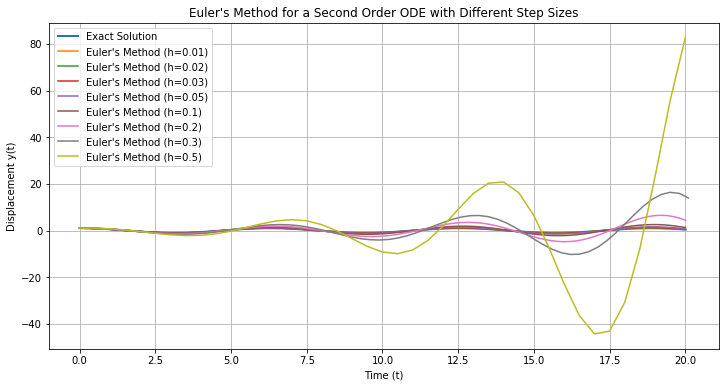

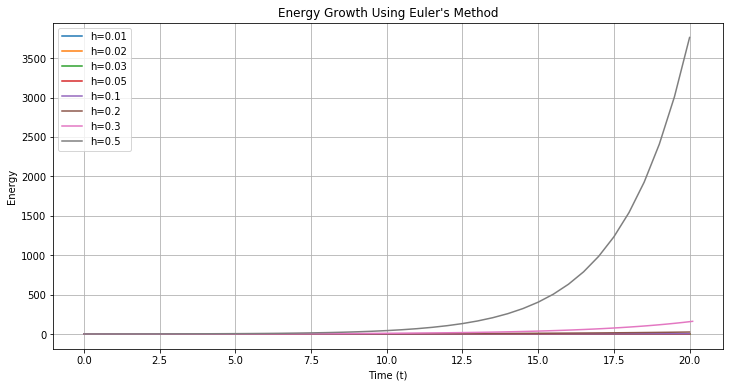

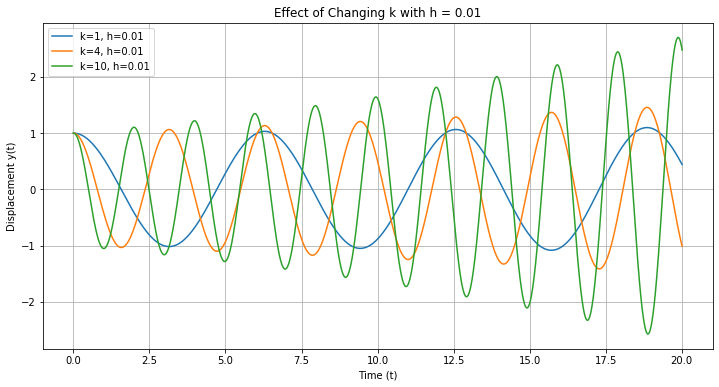

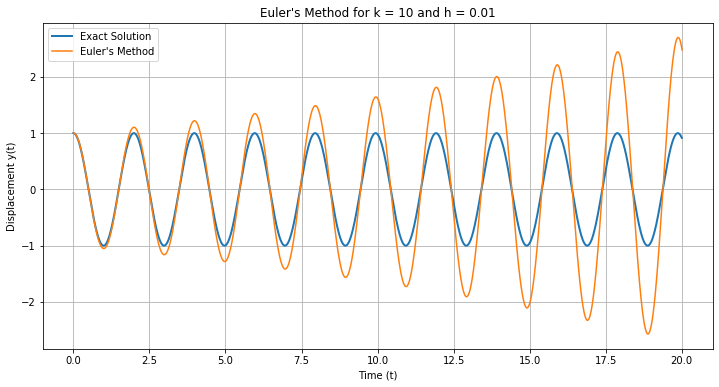

In [11]:
import numpy as np
import matplotlib.pyplot as plt

#parameters
k = 1.0
h_values = [0.01, 0.02, 0.03, 0.05, 0.1, 0.2, 0.3, 0.5]
t_start = 0
t_end = 20
y_0 = 1.0
v_0 = 0.0

#exact solution for y'' = -k y
def exact_solution(t, k, y0=1.0, v0=0.0):
    w = np.sqrt(k)
    return y0 * np.cos(w * t) + (v0 / w) * np.sin(w * t)

#y' = v
#v' = -k y
def euler_method(h, k, t_start, t_end, y_0, v_0):
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros(len(t_values))
    v_values = np.zeros(len(t_values))

    #initial conditions
    y_values[0] = y_0
    v_values[0] = v_0

    for i in range(1, len(t_values)):
        y_n = y_values[i - 1]
        v_n = v_values[i - 1]

        #euler update
        y_values[i] = y_n + h * v_n
        v_values[i] = v_n + h * (-k * y_n)

    return t_values, y_values, v_values

#energy of the oscillator
def energy(y, v, k):
    return 0.5 * v**2 + 0.5 * k * y**2

#plot results for different step sizes
plt.figure(figsize=(12, 6))

t_exact = np.linspace(t_start, t_end, 2000)
y_exact = exact_solution(t_exact, k, y_0, v_0)
plt.plot(t_exact, y_exact, label='Exact Solution', linewidth=2)

for h in h_values:
    t, y, v = euler_method(h, k, t_start, t_end, y_0, v_0)
    plt.plot(t, y, label=f"Euler's Method (h={h})")

plt.xlabel('Time (t)')
plt.ylabel('Displacement y(t)')
plt.title("Euler's Method for a Second Order ODE with Different Step Sizes")
plt.legend()
plt.grid(True)
plt.show()

#plot energy growth to check stability
plt.figure(figsize=(12, 6))

for h in h_values:
    t, y, v = euler_method(h, k, t_start, t_end, y_0, v_0)
    E = energy(y, v, k)
    plt.plot(t, E, label=f'h={h}')

plt.xlabel('Time (t)')
plt.ylabel('Energy')
plt.title("Energy Growth Using Euler's Method")
plt.legend()
plt.grid(True)
plt.show()

#effect of changing k
k_values = [1, 4, 10]
h_fixed = 0.01

plt.figure(figsize=(12, 6))

for k_val in k_values:
    t, y, v = euler_method(h_fixed, k_val, t_start, t_end, y_0, v_0)
    plt.plot(t, y, label=f'k={k_val}, h={h_fixed}')

plt.xlabel('Time (t)')
plt.ylabel('Displacement y(t)')
plt.title("Effect of Changing k with h = 0.01")
plt.legend()
plt.grid(True)
plt.show()

#specific case: k = 10, h = 0.01
k_case = 10
h_case = 0.01

t, y, v = euler_method(h_case, k_case, t_start, t_end, y_0, v_0)
t_exact_case = np.linspace(t_start, t_end, 2000)
y_exact_case = exact_solution(t_exact_case, k_case, y_0, v_0)

plt.figure(figsize=(12, 6))
plt.plot(t_exact_case, y_exact_case, label='Exact Solution', linewidth=2)
plt.plot(t, y, label="Euler's Method")
plt.xlabel('Time (t)')
plt.ylabel('Displacement y(t)')
plt.title("Euler's Method for k = 10 and h = 0.01")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
"""As the step size h rises, Euler's Method loses accuracy. 
The approach is unstable for every h > 0 for the harmonic oscillator y'' = -ky, 
however the instability develops slowly for very tiny h. Plots where the amplitude increases
with time rather than remaining constant demonstrate this. Because Euler's Method causes the 
true energy to grow while it should remain constant, the energy plot likewise exhibits instability. 
The oscillations speed up and the instability becomes more apparent as k increases. Although the approximation 
first appears to be appropriate for k = 10 and h = 0.01, it eventually becomes unstable. 
Consequently, a bigger step size makes it impossible for Euler's Method to solve this issue consistently."""


"As the step size h rises, Euler's Method loses accuracy. \nThe approach is unstable for every h > 0 for the harmonic oscillator y'' = -ky, \nhowever the instability develops slowly for very tiny h. Plots where the amplitude increases\nwith time rather than remaining constant demonstrate this. Because Euler's Method causes the \ntrue energy to grow while it should remain constant, the energy plot likewise exhibits instability. \nThe oscillations speed up and the instability becomes more apparent as k increases. Although the approximation \nfirst appears to be appropriate for k = 10 and h = 0.01, it eventually becomes unstable. \nConsequently, a bigger step size makes it impossible for Euler's Method to solve this issue consistently."